Importamos el csv después del preprocesado y hacemos una breve revisión para ver si nos quedó algo por hacer:
(Pequeñas pruebas de software antes de culminar el proyecto ayuda a que el proceso de prueba y testeo al final 
del proyecto sea más rápido, dado que el equipo de desarrollo es 1 sola persona)

In [1]:
import pandas as pd

df = pd.read_csv("ventas_mensuales_limpio.csv")

print(df.head())


  producto  año_mes  categoria medida  cantidad  total       fecha  mes_n  \
0   Bolsas  2023-03  Panadería      u       191  66.85  2023-03-01      0   
1   Bolsas  2023-04  Panadería      u       146  51.10  2023-04-01      1   
2   Bolsas  2023-05  Panadería      u       173  60.55  2023-05-01      2   
3   Bolsas  2023-06  Panadería      u       172  60.20  2023-06-01      3   
4   Bolsas  2023-07  Panadería      u       229  80.15  2023-07-01      4   

     media_3m  producto_cod  categoria_cod  medida_cod  
0  191.000000             0              5           1  
1  168.500000             0              5           1  
2  170.000000             0              5           1  
3  163.666667             0              5           1  
4  191.333333             0              5           1  


In [2]:
productos_x_mes = df.groupby("año_mes")
print(productos_x_mes.head())

               producto  año_mes  categoria medida  cantidad   total  \
0                Bolsas  2023-03  Panadería      u       191   66.85   
1                Bolsas  2023-04  Panadería      u       146   51.10   
2                Bolsas  2023-05  Panadería      u       173   60.55   
3                Bolsas  2023-06  Panadería      u       172   60.20   
4                Bolsas  2023-07  Panadería      u       229   80.15   
..                  ...      ...        ...    ...       ...     ...   
105        Leche entera  2024-09     Granos      u       159  795.00   
106        Leche entera  2024-10     Granos      u       160  800.00   
107        Leche entera  2024-11     Granos      u       169  845.00   
108        Leche entera  2024-12     Granos      u         1    5.00   
130  Papas precocinadas  2024-12    Lácteos      u        10   31.50   

          fecha  mes_n    media_3m  producto_cod  categoria_cod  medida_cod  
0    2023-03-01      0  191.000000             0         

Procedo con la selección de variables:

In [3]:
#como variable target vamos a elegir "cantidad"
#pues son la cantidad de ventas que se obtienen lo que queremos

#Variable TARGET (la que se desea predecir)
target_name = "cantidad"
y = df[target_name]

#Variables predictoras (las que se usarán para predecir y)
prediction_names = ["mes_n", "media_3m", "producto_cod", "categoria_cod", "medida_cod"]
x = df[prediction_names]

dfforPrediction = df[[target_name]+prediction_names].copy()

print(dfforPrediction.head())

   cantidad  mes_n    media_3m  producto_cod  categoria_cod  medida_cod
0       191      0  191.000000             0              5           1
1       146      1  168.500000             0              5           1
2       173      2  170.000000             0              5           1
3       172      3  163.666667             0              5           1
4       229      4  191.333333             0              5           1


Probaremos con regresión lineal
para ello primero probaremos si existe linealidad en el dataframe con las variables seleccionadas mediante un gráfico de dispersión:

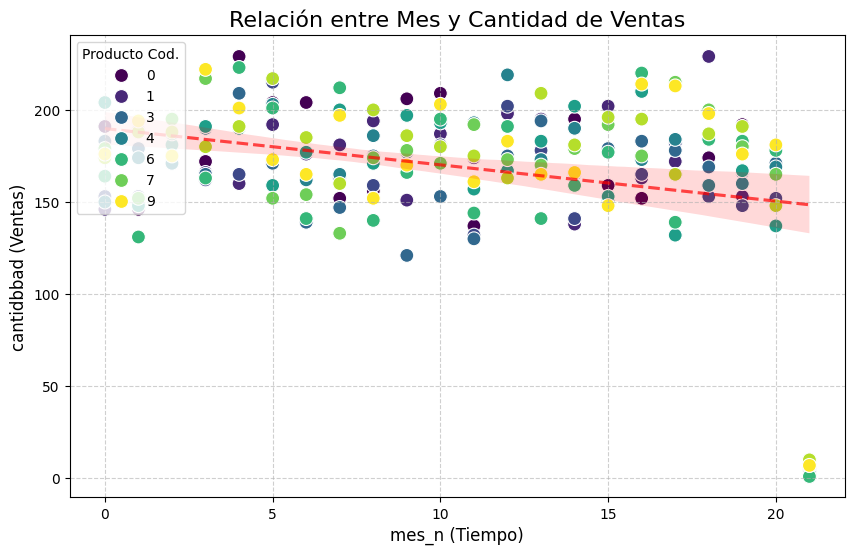

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


plt.figure(figsize=(10, 6))

# Usamos 'hue' para ver si la relación cambia por producto_cod (variable categórica)
sns.scatterplot(x='mes_n', y='cantidad', data=dfforPrediction, hue='producto_cod', palette='viridis', s=100)

# Agregar una línea de regresión lineal para visualizar la tendencia general  (Esto es solo para observar mejor)
sns.regplot(x='mes_n', y='cantidad', data=dfforPrediction, scatter=False, color='red', line_kws={'linestyle': '--', 'alpha': 0.7})

plt.title('Relación entre Mes y Cantidad de Ventas', fontsize=16)
plt.xlabel('mes_n (Tiempo)', fontsize=12)
plt.ylabel('cantidbbad (Ventas)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Producto Cod.', loc='upper left')
plt.show()

Apreciada la linealidad de los datos en el scatter plot, veamos un gráfico de residuos:

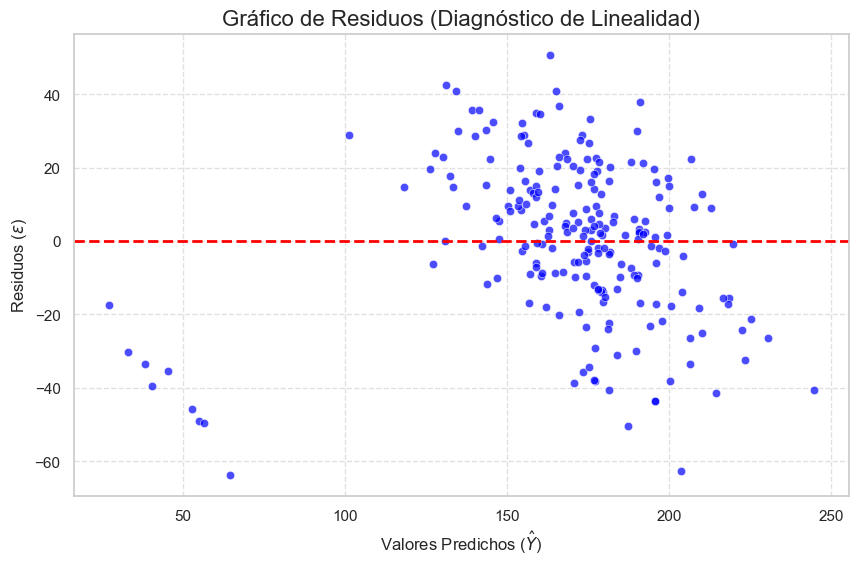


--- Interpretación de la Linealidad ---
Busca una nube de puntos aleatoria alrededor de la línea roja (y=0).
Si ves una curva (forma de 'U'), el supuesto de linealidad ha sido violado.
                            OLS Regression Results                            
Dep. Variable:               cantidad   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     46.33
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           8.33e-50
Time:                        13:16:40   Log-Likelihood:                -983.01
No. Observations:                 219   AIC:                             1990.
Df Residuals:                     207   BIC:                             2031.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                     coe

In [6]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# =========================================================
# PASOS PARA EL GRÁFICO DE RESIDUOS
# =========================================================

# 1. Preparación de Variables Predictoras (X)
X = dfforPrediction.drop(columns=["cantidad"]).copy()
X = pd.get_dummies(X, columns=['producto_cod'], drop_first=True) 

# PASO CLAVE DE CORRECCIÓN: CONVERTIR TODA LA MATRIZ X A FLOAT
# Esto garantiza que no quede ninguna columna de tipo 'object'
X = X.astype(float) 

# Agregamos la constante (el intercepto B0) al modelo
X = sm.add_constant(X)

# Nos aseguramos que Y también sea float
Y = dfforPrediction['cantidad'].astype(float)

# 1.1 Separar el conjunto de datos

# 2. Ajuste del Modelo de Regresión Lineal (OLS)
modelo = sm.OLS(Y, X).fit()

# 3. Obtener los Residuos y Valores Predichos
residuos = modelo.resid
valores_predichos = modelo.fittedvalues

# 4. Crear el Gráfico de Residuos
plt.figure(figsize=(10, 6))

# Trazamos los Residuos (Y) vs. Valores Predichos (X)
# Este es el gráfico de diagnóstico estándar para linealidad y homocedasticidad.
sns.scatterplot(x=valores_predichos, y=residuos, color='blue', alpha=0.7)

# Línea de referencia horizontal en y=0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Gráfico de Residuos (Diagnóstico de Linealidad)', fontsize=16)
# CÓDIGO CON LA CORRECCIÓN:
plt.xlabel(r'Valores Predichos ($\hat{Y}$)', fontsize=12)
plt.ylabel(r'Residuos ($\epsilon$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- Interpretación de la Linealidad ---")
print("Busca una nube de puntos aleatoria alrededor de la línea roja (y=0).")
print("Si ves una curva (forma de 'U'), el supuesto de linealidad ha sido violado.")
print(modelo.summary()) # Descomenta para ver todas las estadísticas del modelo

Confirmada la linealidad, procedemos a entrenar un modelo de regresión lineal para hacer el forecasting.

In [7]:
#Este modulo lo usaré para dividir el conjunto de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,y, test_size = 0.2, random_state=42
)


# Paso 2: Escalado (opcional pero recomendado)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Paso 3: Entrenar modelo (Regresión Lineal)
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Paso 4: Predecir
y_pred = modelo.predict(X_test_scaled)

# Paso 5: Evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Métricas del modelo:")
print(f"➡️  Error cuadrático medio (MSE): {mse:.2f}")
print(f"➡️  Error absoluto medio (MAE): {mae:.2f}")
print(f"➡️  R2 (explicación de la varianza): {r2:.2f}")


📊 Métricas del modelo:
➡️  Error cuadrático medio (MSE): 582.96
➡️  Error absoluto medio (MAE): 19.28
➡️  R2 (explicación de la varianza): 0.64


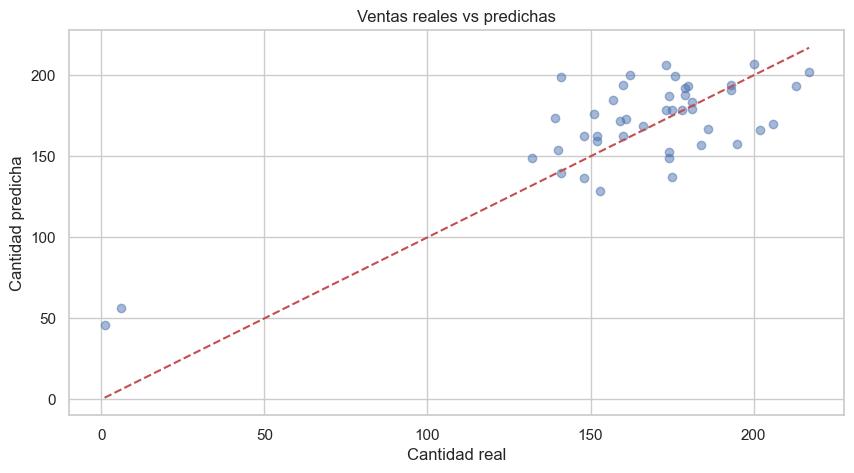

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Cantidad real")
plt.ylabel("Cantidad predicha")
plt.title("Ventas reales vs predichas")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # línea perfecta
plt.grid(True)
plt.savefig("grafico_pred_vs_real.png", dpi=300, bbox_inches='tight')
plt.show()

El algoritmo tiene un buen punto de partida pero no es óptimo.
Se procede a hacer reajustes y analizar las variables elegidas.

Vuelvo a proceder a seleccionar variables pero con diferencia de la primera vez.

In [9]:
#como variable target vamos a elegir "cantidad"
#pues son la cantidad de ventas que se obtienen lo que queremos

#Variable TARGET (la que se desea predecir)
target_name = "cantidad"
y = df[target_name]

#Variables predictoras (las que se usarán para predecir y)
prediction_names = ["mes_n", "producto_cod", "categoria_cod", "medida_cod"]
x = df[prediction_names]
#Desestimo media_3m

dfforPrediction = df[[target_name]+prediction_names].copy()

print(dfforPrediction.head())

   cantidad  mes_n  producto_cod  categoria_cod  medida_cod
0       191      0             0              5           1
1       146      1             0              5           1
2       173      2             0              5           1
3       172      3             0              5           1
4       229      4             0              5           1


Reentreno un modelo de RL

📊 Métricas del modelo:
➡️  Error cuadrático medio (MSE): 1462.41
➡️  Error absoluto medio (MAE): 24.90
➡️  R2 (explicación de la varianza): 0.10


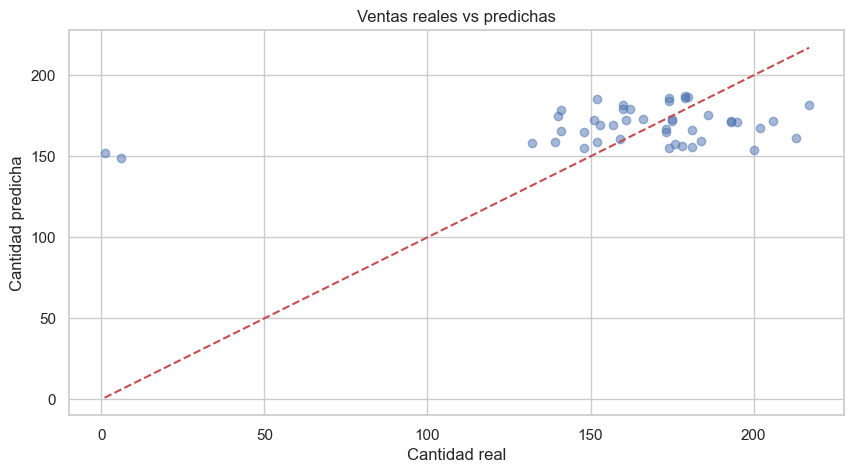

In [10]:
#Este modulo lo usaré para dividir el conjunto de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,y, test_size = 0.2, random_state=42
)


# Paso 2: Escalado (opcional pero recomendado)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Paso 3: Entrenar modelo (Regresión Lineal)
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Paso 4: Predecir
y_pred = modelo.predict(X_test_scaled)

# Paso 5: Evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Métricas del modelo:")
print(f"➡️  Error cuadrático medio (MSE): {mse:.2f}")
print(f"➡️  Error absoluto medio (MAE): {mae:.2f}")
print(f"➡️  R2 (explicación de la varianza): {r2:.2f}")
# y muestro el gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Cantidad real")
plt.ylabel("Cantidad predicha")
plt.title("Ventas reales vs predichas")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # línea perfecta
plt.grid(True)
plt.savefig("grafico_pred_vs_real.png", dpi=300, bbox_inches='tight')
plt.show()

Los resultados son peores. La variable media_3m si impacta al predecir ventas.